# Stationwise evaluation

Use the reusable functions from `compile_results_functions.py` to evaluate predictions overall and per station without rebuilding the long notebook workflow.

In [1]:
from pathlib import Path
import os
import sys

import pandas as pd

# Make the helper module importable when running the notebook from VS Code.
NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

from compile_results_functions import (
    build_waveform_index,
    compute_metrics,
    format_metrics_report,
    load_prediction_csvs,
    merge_predictions_and_truth,
    plot_pred_row,
    prepare_long_predictions,
)


/home/akuburas/miniconda3/envs/eqcctpro-tf/lib/python3.10/site-packages/obspy/core/util/base.py:26: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# Core configuration
waveform_type = "earthquakes"
model_type = "eqcct"

base_path = "../results/csv"
data_dir = f"../data/waveforms_{waveform_type}_nonoise"
gt_path = Path(base_path) / "ground_truth"

subdir = f"{model_type}_{waveform_type}_th0_1"
gt_fname = f"{subdir}.csv"

# Keep the notebook read-only by default.
# Flip this to True only if you explicitly want to write derived CSV files.
save_outputs = False
csv_output_path = os.path.join(base_path, "combined") if save_outputs else None
csv_output_name = f"{subdir}_full.csv" if save_outputs else None

time_threshold = "10s"

# Control how the stationwise table is sorted.
# Set sort_columns to None to keep the original order.
sort_columns = ["f1_score", "precision", "recall"]
sort_ascending = [False, False, False]


In [3]:
def evaluate_station(group_df, truth_df, *, p_threshold=0.1, time_threshold="10s"):
    """Evaluate one station group and return a metrics dictionary."""

    if group_df.empty:
        return None

    row0 = group_df.iloc[0]
    station_truth = truth_df[
        (truth_df["network"] == row0.network) & (truth_df["station"] == row0.station)
    ]

    if station_truth.empty:
        return None

    station_pred_long = prepare_long_predictions(group_df, p_threshold=p_threshold)
    station_preds_on_picks, station_picks_on_preds = merge_predictions_and_truth(
        station_pred_long,
        station_truth,
        time_threshold=time_threshold,
    )
    metrics = compute_metrics(station_preds_on_picks, station_picks_on_preds)

    metrics["network"] = row0.network
    metrics["station"] = row0.station
    metrics["num_rows"] = len(group_df)
    metrics["num_true_picks"] = len(station_truth)
    metrics["num_predictions"] = len(station_pred_long)
    return metrics

In [4]:
# Load and normalize the prediction CSVs.
df_predictions = load_prediction_csvs(
    base_path,
    subdir,
    csv_output_path=csv_output_path,
    csv_output_name=csv_output_name,
)

p_threshold = 0.1

# Build the waveform index if you want to plot individual stations later.
waveform_idx = build_waveform_index(data_dir)

# Load the existing ground-truth CSV from results/csv/ground_truth.
gt_file = gt_path / gt_fname
if not gt_file.exists():
    raise FileNotFoundError(f"Missing ground-truth CSV: {gt_file.resolve()}")

df_true = pd.read_csv(gt_file)
if not df_true.empty:
    df_true["true_arrival_time"] = pd.to_datetime(df_true["true_arrival_time"], errors="coerce")
    df_true = df_true.dropna(subset=["true_arrival_time", "network", "station", "phase"])
    df_true["network"] = df_true["network"].astype(str).str.strip().str.upper()
    df_true["station"] = df_true["station"].astype(str).str.strip().str.upper()
    df_true["phase"] = df_true["phase"].astype(str).str.strip().str.upper()

# Evaluate the full dataset.
df_pred_long = prepare_long_predictions(df_predictions, p_threshold=p_threshold)
preds_on_picks, picks_on_preds = merge_predictions_and_truth(
    df_pred_long,
    df_true,
    time_threshold=time_threshold,
)
metrics = compute_metrics(preds_on_picks, picks_on_preds)
metrics_string = format_metrics_report(metrics, subdir)
print(metrics_string)

# Stationwise metrics.
station_metrics = []
for _, group_df in df_predictions.groupby(["network", "station"]):
    station_result = evaluate_station(
        group_df,
        df_true,
        p_threshold=p_threshold,
        time_threshold=time_threshold,
    )
    if station_result is not None:
        station_metrics.append(station_result)

station_metrics_df = pd.DataFrame(station_metrics)
if not station_metrics_df.empty and sort_columns is not None:
    station_metrics_df = station_metrics_df.sort_values(sort_columns, ascending=sort_ascending)
    display(station_metrics_df)
elif not station_metrics_df.empty:
    display(station_metrics_df)

# Keep the results in memory unless you explicitly enable save_outputs.
if save_outputs and not station_metrics_df.empty:
    station_metrics_path = os.path.join(base_path.replace("csv", "metrics"), f"{subdir}_stationwise.csv")
    os.makedirs(os.path.dirname(station_metrics_path), exist_ok=True)
    station_metrics_df.to_csv(station_metrics_path, index=False)
    print(f"Saved stationwise metrics to {station_metrics_path}")


Evaluated predictions from: eqcct_earthquakes_th0_1

=========== Overall metrics ===========
True Positives:        2884
False Positives:       611
False Negatives:       1127
Total predictions:     3495
Total picks:           4011
Recall:                0.7190226876090751
Precision:             0.8251788268955651
F1 Score:              0.7684519051425527

=========== Metrics for p-picks ===========
True Positives:        1458
False Positives:       578
False Negatives:       120
Total predictions:     2036
Total picks:           1578
Recall:                0.9239543726235742
Precision:             0.7161100196463654
F1 Score:              0.8068622025456558

=========== Metrics for s-picks ===========
True Positives:        1426
False Positives:       33
False Negatives:       1007
Total predictions:     1459
Total picks:           2433
Recall:                0.5861076859843815
Precision:             0.9773817683344757
F1 Score:              0.7327852004110997



,TP,FP,FN,num_preds,num_picks,recall,precision,f1_score,TP_p,TP_s,...,recall_s,precision_p,precision_s,f1_score_p,f1_score_s,network,station,num_rows,num_true_picks,num_predictions
2,93,8,13,101,106,0.877358,0.920792,0.898551,48,45,...,0.775862,0.857143,1.000000,0.923077,0.873786,FN,MSF,56,106,101
21,83,8,12,91,95,0.873684,0.912088,0.892473,41,42,...,0.792453,0.854167,0.976744,0.911111,0.875000,HE,KU6,49,95,91
3,97,11,15,108,112,0.866071,0.898148,0.881818,47,50,...,0.793651,0.810345,1.000000,0.878505,0.884956,FN,OLKF,59,112,108
18,52,2,12,54,64,0.812500,0.962963,0.881356,27,25,...,0.694444,0.900000,1.041667,0.931034,0.833333,HE,KEV,30,64,54
38,94,14,17,108,111,0.846847,0.870370,0.858447,48,46,...,0.741935,0.813559,0.938776,0.888889,0.828829,HE,VAF,59,111,108
39,90,3,28,93,118,0.762712,0.967742,0.853081,45,45,...,0.692308,0.918367,1.022727,0.882353,0.825688,HE,VJF,49,118,93
6,145,19,33,164,178,0.814607,0.884146,0.847953,71,74,...,0.718447,0.797753,0.986667,0.865854,0.831461,FN,RANF,94,178,164
19,90,20,15,110,105,0.857143,0.818182,0.837209,41,49,...,0.765625,0.694915,0.960784,0.820000,0.852174,HE,KIF,59,105,110
12,141,21,35,162,176,0.801136,0.870370,0.834320,71,70,...,0.693069,0.788889,0.972222,0.860606,0.809249,HE,HEF,92,176,162
7,153,23,40,176,193,0.792746,0.869318,0.829268,77,76,...,0.678571,0.777778,0.987013,0.855556,0.804233,FN,RNF,101,193,176


Inspecting station: HE.JOF (F1=0.522, precision=0.600, recall=0.462, predictions=10)
False-negative picks for HE.JOF: 7


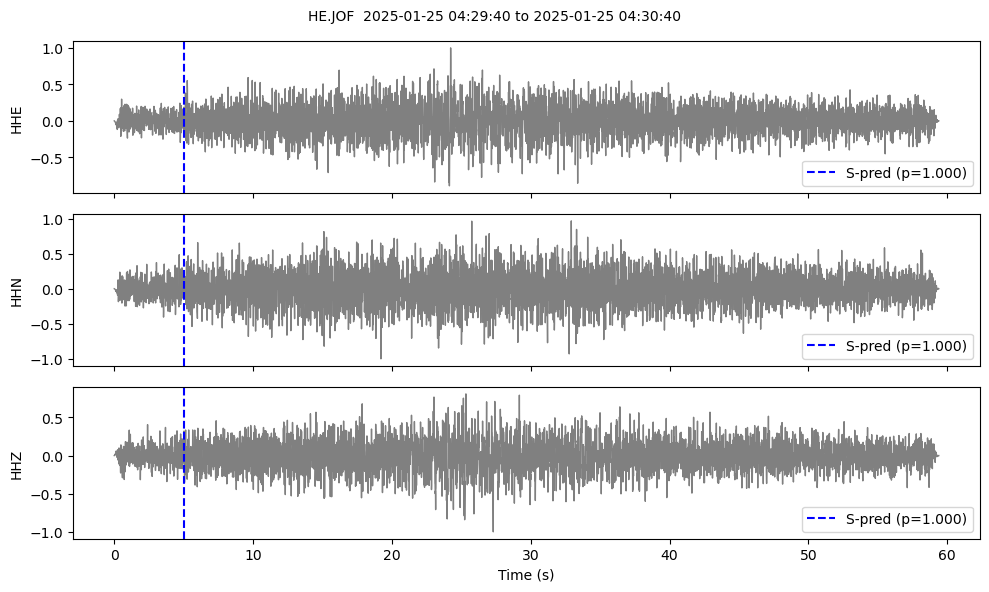

Skipped HE.JOF 2025-06-07 19:16:18.353890 because no prediction window covered that true pick.
Skipped HE.JOF 2025-06-07 19:16:46.723190 because no prediction window covered that true pick.


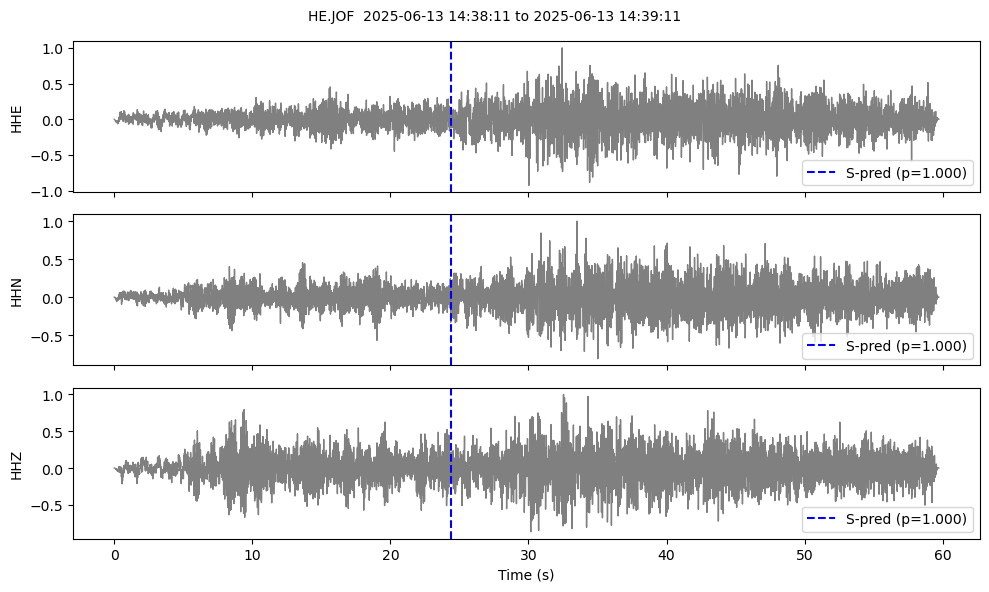

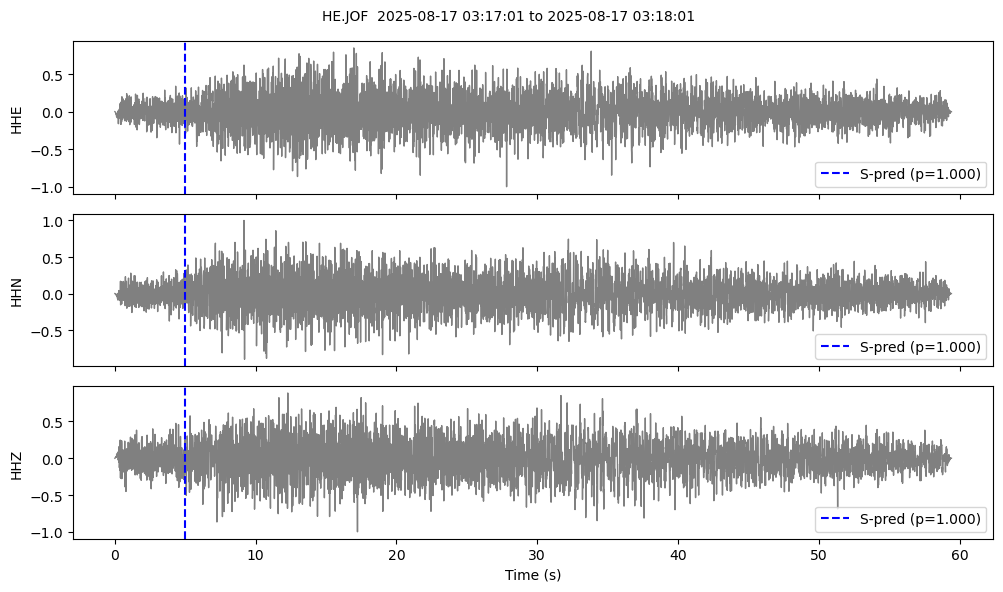

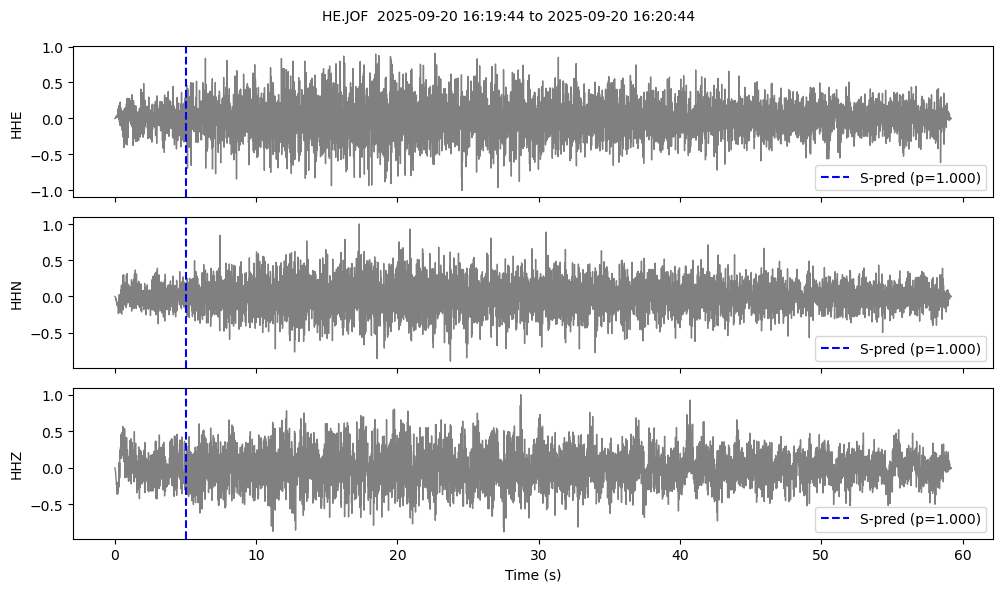

Skipped HE.JOF 2025-12-26 11:13:32.168320 because no prediction window covered that true pick.


In [5]:
# Plot missed detections or false alarms for a user-selected station.
station_to_inspect = "HE.JOF"  # format: "NET.STA"
inspect_mode = "false_negative"  # "false_positive" or "false_negative"
max_plots = 20

if station_metrics_df.empty:
    print("No stationwise metrics available yet.")
else:
    station_text = str(station_to_inspect).strip().upper()
    if "." not in station_text:
        raise ValueError(
            "station_to_inspect must be in 'NET.STA' format, for example 'HE.RSUO'."
        )

    selected_network, selected_station = station_text.split(".", 1)
    mode = str(inspect_mode).strip().lower()
    if mode not in {"false_positive", "false_negative"}:
        raise ValueError("inspect_mode must be either 'false_positive' or 'false_negative'.")

    station_candidates = station_metrics_df[
        (station_metrics_df["network"].astype(str).str.upper() == selected_network)
        & (station_metrics_df["station"].astype(str).str.upper() == selected_station)
    ]

    if station_candidates.empty:
        raise ValueError(
            f"Station '{station_to_inspect}' not found in station_metrics_df. "
            "Check station_metrics_df[['network', 'station']] for available values."
        )

    chosen_row = station_candidates.sort_values(
        ["f1_score", "precision", "recall"],
        ascending=[True, True, True],
    ).iloc[0]

    print(
        f"Inspecting station: {selected_network}.{selected_station} "
        f"(F1={chosen_row['f1_score']:.3f}, "
        f"precision={chosen_row['precision']:.3f}, "
        f"recall={chosen_row['recall']:.3f}, "
        f"predictions={int(chosen_row['num_predictions'])})"
    )

    station_predictions = df_predictions[
        (df_predictions["network"] == selected_network)
        & (df_predictions["station"] == selected_station)
    ].copy()
    if not station_predictions.empty:
        station_predictions["start_dt"] = pd.to_datetime(station_predictions["start_dt"], errors="coerce")
        station_predictions["end_dt"] = pd.to_datetime(station_predictions["end_dt"], errors="coerce")

    station_pred_long = prepare_long_predictions(
        station_predictions,
        p_threshold=p_threshold,
    )

    station_truth = df_true[
        (df_true["network"] == selected_network)
        & (df_true["station"] == selected_station)
    ]

    station_preds_on_picks, station_picks_on_preds = merge_predictions_and_truth(
        station_pred_long,
        station_truth,
        time_threshold=time_threshold,
    )

    if mode == "false_positive":
        selected_rows = station_preds_on_picks[
            station_preds_on_picks["true_arrival_time"].isna()
        ].copy()
        selected_rows = selected_rows.sort_values("pred_arrival_time")
        print(
            f"False-positive predictions for {selected_network}.{selected_station}: "
            f"{len(selected_rows)}"
        )
    else:
        selected_rows = station_picks_on_preds[
            station_picks_on_preds["probability"].isna()
        ].copy()
        selected_rows = selected_rows.sort_values("true_arrival_time")
        print(
            f"False-negative picks for {selected_network}.{selected_station}: "
            f"{len(selected_rows)}"
        )

    if selected_rows.empty:
        print(f"No {mode.replace('_', ' ')} samples found for this station.")
    else:
        num_plots = min(max_plots, len(selected_rows))
        for _, row in selected_rows.head(num_plots).iterrows():
            if mode == "false_positive":
                start_dt = row.start_dt
                end_dt = row.end_dt
                phase = row.phase
                arrival_time = row.pred_arrival_time
                probability = row.probability
            else:
                phase = row.phase
                arrival_time = row.true_arrival_time
                probability = 1.0  # Ensure marker is plotted for missed true picks.
                matching_windows = station_predictions[
                    (station_predictions["start_dt"] <= arrival_time)
                    & (station_predictions["end_dt"] >= arrival_time)
                ]
                if matching_windows.empty:
                    print(
                        f"Skipped {row.network}.{row.station} {arrival_time} "
                        "because no prediction window covered that true pick."
                    )
                    continue
                window_row = matching_windows.iloc[0]
                start_dt = window_row.start_dt
                end_dt = window_row.end_dt

            row_dict = {
                "network": row.network,
                "station": row.station,
                "start_dt": start_dt,
                "end_dt": end_dt,
                "p_arrival_time": pd.NaT,
                "s_arrival_time": pd.NaT,
                "p_probability": None,
                "s_probability": None,
            }
            if phase == "P":
                row_dict["p_arrival_time"] = arrival_time
                row_dict["p_probability"] = probability
            elif phase == "S":
                row_dict["s_arrival_time"] = arrival_time
                row_dict["s_probability"] = probability

            plotted = plot_pred_row(pd.Series(row_dict), waveform_idx, p_tr=p_threshold)
            if not plotted:
                print(
                    f"Skipped {row.network}.{row.station} {arrival_time} "
                    "because the waveform could not be loaded."
                )
